# Predicting PM2.5 Exposure in London Using Urban Spatial Features

**GitHub repository link:**  

https://github.com/Yesw11/urban5160-pm25-project

## 1. Introduction

PM2.5 is a key indicator of urban air pollution because fine particles can penetrate deeply into the respiratory system and are associated with serious health risks, including respiratory and cardiovascular diseases (WHO, 2021). In dense urban environments, PM2.5 exposure is rarely evenly distributed. It is shaped by traffic emissions, land use, built density, and population activities, producing clear spatial variation within cities. Understanding this small-area variation is important because city-wide averages may hide local pollution hotspots and unequal exposure risks.

London provides a useful case for this analysis because it is a large, dense, and spatially diverse metropolis with complex transport and land-use patterns. This study uses PM2.5 concentration data at the Output Area (OA) level and combines it with OA boundary data to construct simple spatial features, including area size, centroid coordinates, distance to central London, and borough information. The OA scale is useful because it captures finer local variation than borough-level averages.

The main research question is: to what extent can basic urban spatial features predict PM2.5 exposure across London OAs? To answer this question, the study cleans and merges spatial data, creates GIS-based features, explores the spatial distribution of PM2.5, and compares three predictive approaches: Mean Baseline, Linear Regression, and Random Forest. Model performance is assessed using MAE, RMSE, and R². The aim is not to build a complete causal model of air pollution, but to test whether a simple and reproducible urban analytics workflow can produce useful small-area PM2.5 predictions.



## 2. Data and Research Design

This study uses two main datasets. The first is London OA-level PM2.5 concentration data, which provides the dependent variable for the prediction task. The second is the 2011 London OA boundary dataset, which provides the geometry and spatial location of each OA. These datasets are joined using OA codes, producing a spatial dataset in which each OA has both a PM2.5 value and a polygon boundary.

The OA is selected as the unit of analysis because it provides a much finer spatial resolution than boroughs or other larger administrative areas. This is important in air pollution research, as pollution levels can vary substantially over short distances. Hoek et al. (2008) note that GIS-based variables are commonly used in exposure modelling because they help explain spatial variation in pollution levels at small scales.

The dependent variable in this study is PM2.5 concentration. The explanatory variables are derived from the boundary data and include OA area, centroid x and y coordinates, distance from the OA centroid to central London, and borough dummy variables. These variables do not capture all possible pollution sources, such as traffic volume, road density, weather, or land use. However, they provide a clear and interpretable set of spatial predictors for testing whether basic location-based features can explain PM2.5 variation across London.



In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import os
from shapely.geometry import Point
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# These are the local file paths.
# The PM2.5 file is the csv from London Datastore.
# The map folder is the unzipped London statistical GIS boundary folder.
# If the files are saved somewhere else, only change these two lines.

p_fp = "data/OA2_PM25_2013.csv"
m_fd = "data/statistical-gis-boundaries-london"

# all figures and tables made by the notebook are saved here
op = "outputs"
os.makedirs(op, exist_ok=True)

# I use a small loop to find the OA shapefile.
# This avoids printing a long file list in the final HTML.
# The important point is: the file must be OA 2011, not LSOA or MSOA.
# If this automatic path does not work, manually write the shapefile path in o_fp.

o_fp = None

for r, ds, fs in os.walk(m_fd):
    for f in fs:
        fn = f.lower()
        if fn.endswith(".shp"):
            if "oa" in fn and "2011" in fn and "lsoa" not in fn and "msoa" not in fn:
                o_fp = os.path.join(r, f)
                break
    if o_fp is not None:
        break


## 3. Data Cleaning and Feature Engineering

Data cleaning focused first on ensuring that the spatial join was correct. Since the PM2.5 table and OA boundary file came from different sources, OA codes were checked and used as the common key for merging. After the join, OAs with missing PM2.5 values were removed. This is appropriate because PM2.5 is the target variable, and records without a target value cannot be used in supervised prediction. The purpose of this study is not to impute missing pollution values, but to model observed PM2.5 variation.

The spatial data were then converted to the British National Grid projected coordinate system. This step is necessary because area and distance should be calculated in a projected coordinate system rather than directly from latitude and longitude. After projection, the area of each OA was calculated from its polygon geometry, and centroid coordinates were extracted to represent its location within London.

The distance from each OA centroid to central London was also calculated. This variable represents a simple centre–periphery measure. It may be relevant because central areas often contain higher levels of transport activity, built density, and mixed land use. Borough names were also converted into dummy variables to capture broader local differences between administrative areas. Overall, the feature engineering strategy follows the logic of GIS-based exposure modelling: using spatial position and geographical features to explain variation in air pollution concentrations (Hoek et al., 2008).

In [3]:
# Read the csv file and the shapefile.
# p is the pollution data.
# o is the Output Area boundary data.

p = pd.read_csv(p_fp)
o = gpd.read_file(o_fp)

# remove accidental spaces in column names
# this is a small cleaning step, because sometimes csv column names contain spaces
p.columns = p.columns.str.strip()
o.columns = o.columns.str.strip()

# The two data sources are joined by OA11CD.
# In the PM2.5 csv, the pollutant column is usually called PM25.
# The fallback line is kept because sometimes the column name may contain a dot, such as PM2.5.

pc = "OA11CD"
yc = "PM25"

if yc not in p.columns:
    for c in p.columns:
        cc = c.upper().replace(".", "")
        if "PM25" in cc or "PM2" in cc:
            yc = c
            break

# keep only the columns needed from the pollution table
# after this, p1 has one row for each Output Area and one PM2.5 value
p1 = p[[pc, yc]].copy()
p1.columns = ["oa", "pm25"]

# make sure the join code is text on both sides
# this avoids small merge problems caused by different data types
p1["oa"] = p1["oa"].astype(str).str.strip()
o[pc] = o[pc].astype(str).str.strip()

# make PM2.5 numeric
# any strange non-numeric value would become missing here
y = pd.to_numeric(p1["pm25"], errors="coerce")
p1["pm25"] = y

# merge the PM2.5 values into the boundary polygons
# g is the main spatial dataset used in the rest of the project

g = o.merge(p1, left_on=pc, right_on="oa", how="left")

# keep only areas where PM2.5 is available
# this is the main cleaning decision for the dependent variable

g = g.dropna(subset=["pm25"]).copy()

# remove empty geometry, because those rows cannot be mapped or used for spatial features

g = g[g.geometry.notna()].copy()


## 4. Exploratory Data Analysis

The exploratory data analysis shows that the cleaned dataset contains 25,946 OAs. The mean PM2.5 concentration is approximately 16.00, with a standard deviation of about 0.79. The minimum and maximum values are around 14.28 and 21.10, respectively. This suggests that although the overall variation is not extremely large, some areas experience noticeably higher exposure than the London average.

The histogram shows that PM2.5 values are concentrated around the middle range, with a slight right-skewed pattern. This means most OAs have pollution levels close to the average, while a smaller number of areas have higher concentrations. This matters because average values alone do not reveal local exposure inequality. Even when the overall distribution seems relatively narrow, high-exposure areas may still represent important environmental and public health concerns.

The spatial map further confirms that PM2.5 is not randomly distributed across London. Some parts of the city show higher concentrations, while other areas, especially some peripheral locations, show lower values. This supports the idea that urban pollution is spatially structured and may be related to location, density, and accessibility. The scatter plot between PM2.5 and distance to central London also provides useful evidence. Although distance to the centre is not a direct pollution source, it captures part of the centre–periphery structure of the city. However, the relationship does not appear perfectly linear, which suggests that a simple linear model may not capture all spatial variation. This provides a reason for comparing Linear Regression with a more flexible model such as Random Forest.

In [4]:
# descriptive statistics for the dependent variable
# this table gives the basic spread of PM2.5 across London Output Areas
s1 = g[["pm25"]].describe().round(3)
s1


,pm25
count,25946.000
mean,16.001
std,0.789
min,14.283
25%,15.418
50%,15.873
75%,16.465
max,21.100


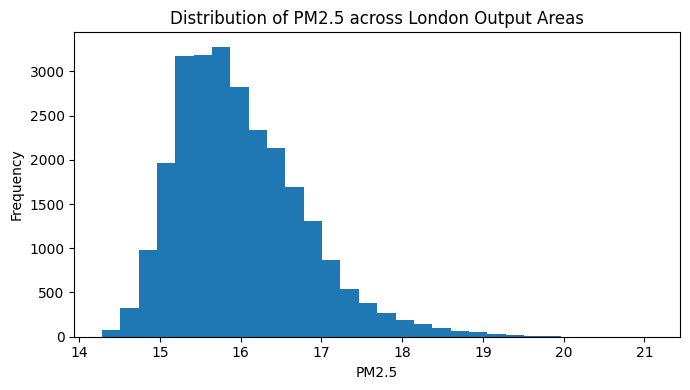

In [5]:
# Histogram of PM2.5.
# This figure shows whether PM2.5 values are concentrated or spread out.
# It is useful before modelling because the model is trying to predict this variable.

plt.figure(figsize=(7,4))
plt.hist(g["pm25"], bins=30)
plt.xlabel("PM2.5")
plt.ylabel("Frequency")
plt.title("Distribution of PM2.5 across London Output Areas")
plt.tight_layout()
plt.savefig(op + "/pm25_hist.png", dpi=200)
plt.show()


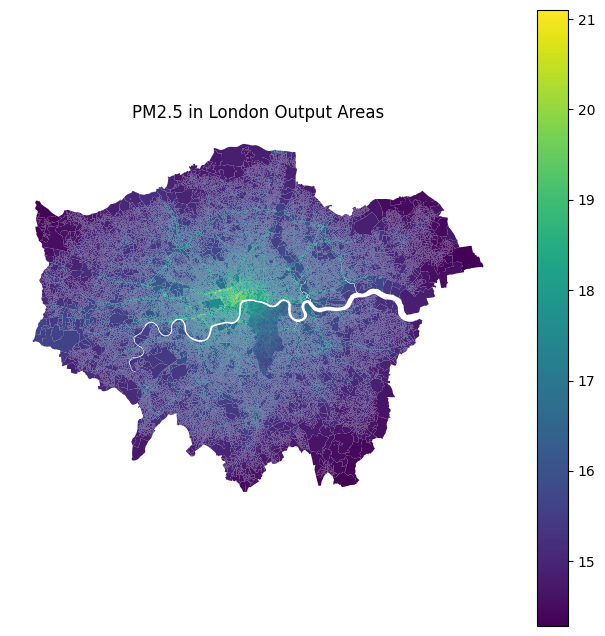

In [6]:
# Map of PM2.5.
# Each polygon is an Output Area.
# The map is important because PM2.5 is a spatial environmental variable.

g.plot(column="pm25", legend=True, figsize=(8,8))
plt.title("PM2.5 in London Output Areas")
plt.axis("off")
plt.savefig(op + "/pm25_map.png", dpi=200, bbox_inches="tight")
plt.show()


## 5. Modelling Strategy

Three models are used in this study: Mean Baseline, Linear Regression, and Random Forest. The Mean Baseline is included as a minimum benchmark. It does not use any predictors and simply predicts the mean PM2.5 value from the training data. If other models do not clearly outperform this baseline, the constructed spatial features would have limited predictive value.

Linear Regression is used as the first formal prediction model. It is simple, interpretable, and useful for testing whether PM2.5 can be explained by a linear combination of the spatial features. However, urban air pollution is influenced by multiple processes, and relationships between spatial location and pollution may be non-linear.

Random Forest is used as the main machine learning model. It is an ensemble method based on multiple decision trees and can capture non-linear relationships and interactions between variables (Breiman, 2001). In this study, Random Forest is not treated as a causal model. Instead, it is used to test whether the same simple spatial features can produce stronger predictive performance when modelled in a more flexible way.

Model performance is evaluated using MAE, RMSE, and R². MAE measures the average prediction error, RMSE gives more weight to larger errors, and R² measures the proportion of PM2.5 variation explained by the model. These three metrics together provide a balanced comparison of model accuracy and explanatory performance.



In [7]:
# The boundary file needs to be in a projected coordinate system before calculating area and distance.
# EPSG:27700 is British National Grid, which is suitable for London distance calculation.
# The code below makes sure the geometry is in that CRS.

if g.crs is None:
    g = g.set_crs(27700)

g = g.to_crs(27700)

# area feature: larger and smaller Output Areas may represent different urban forms
# area is converted from square metres to square kilometres

g["ak"] = g.geometry.area / 1000000

# centroid is used to create simple spatial location variables
# this is not a complex spatial model, but it gives the model some location information

g["ct"] = g.geometry.centroid
g["x"] = g["ct"].x
g["y"] = g["ct"].y

# create a London centre point using longitude and latitude
# then project it to the same CRS as the polygons

cp = gpd.GeoSeries([Point(-0.1276, 51.5072)], crs=4326)
cp = cp.to_crs(g.crs).iloc[0]

# distance to central London, in kilometres
# this is a simple urban spatial feature: central and outer areas may have different exposure levels

g["dc"] = g["ct"].distance(cp) / 1000

# add two small hand-made features
# dc2 lets the linear model capture a curved distance effect
# la is log area, because area can be skewed

g["dc2"] = g["dc"] * g["dc"]
g["la"] = np.log1p(g["ak"])

# rough east/west and north/south indicators
# these are simple binary spatial variables made from the median x and y coordinates

g["e"] = (g["x"] > g["x"].median()).astype(int)
g["n"] = (g["y"] > g["y"].median()).astype(int)


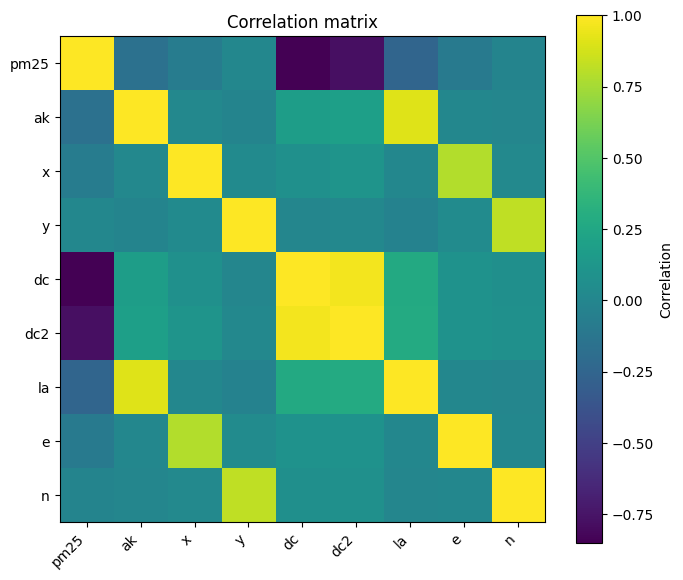

In [8]:
# A small correlation matrix for the numeric variables.
# This is not used to remove variables automatically.
# It is mainly used to understand the relationship between PM2.5 and the spatial features.

c0 = ["pm25", "ak", "x", "y", "dc", "dc2", "la", "e", "n"]
cr = g[c0].corr()

plt.figure(figsize=(7,6))
plt.imshow(cr)
plt.xticks(range(len(cr.columns)), cr.columns, rotation=45, ha="right")
plt.yticks(range(len(cr.columns)), cr.columns)
plt.colorbar(label="Correlation")
plt.title("Correlation matrix")
plt.tight_layout()
plt.savefig(op + "/corr_matrix.png", dpi=200)
plt.show()


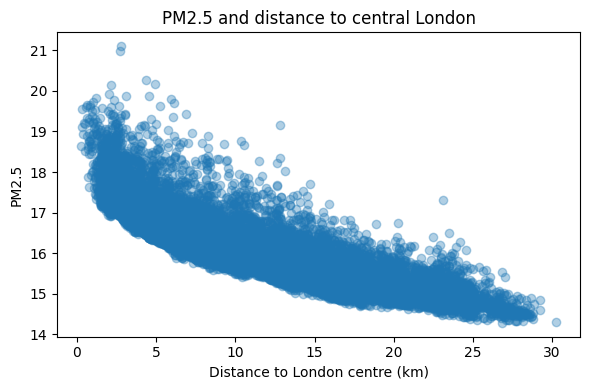

In [9]:
# PM2.5 and distance to the centre.
# This plot is useful because distance to centre is one of the main handmade spatial features.

plt.figure(figsize=(6,4))
plt.scatter(g["dc"], g["pm25"], alpha=0.35)
plt.xlabel("Distance to London centre (km)")
plt.ylabel("PM2.5")
plt.title("PM2.5 and distance to central London")
plt.tight_layout()
plt.savefig(op + "/pm25_distance.png", dpi=200)
plt.show()


## 6. Model Evaluation and Interpretation

The results show a clear improvement from the baseline model to the machine learning model. The Mean Baseline has an MAE of 0.6184, an RMSE of 0.7891, and an R² close to zero. This confirms that using only the mean value cannot explain PM2.5 differences across OAs.

Linear Regression performs much better, with an MAE of 0.2329, an RMSE of 0.3305, and an R² of 0.8245. This indicates that the spatial features constructed in this study explain a substantial share of PM2.5 variation. In other words, even simple GIS-based variables contain useful information about pollution exposure differences across London.

Random Forest achieves the best performance, with an MAE of 0.1619, an RMSE of 0.2414, and an R² of 0.9064. Compared with Linear Regression, it reduces both average error and larger prediction errors, while also increasing the explained variance. This suggests that the relationship between PM2.5 and spatial features is not fully linear. Random Forest is better able to capture non-linear spatial patterns and interactions between variables.

The actual-versus-predicted plots support this result. Linear Regression broadly follows the observed PM2.5 values, but its predictions show more deviation at some high and low values. Random Forest predictions are more closely distributed around the ideal diagonal line, indicating better predictive stability. The feature importance results also show that location-related variables, including centroid coordinates, distance to the centre, and borough information, contribute meaningfully to prediction.

However, these results should be interpreted carefully. Feature importance does not prove causality. It only shows which variables the model relies on during prediction. The residual map and absolute error map are therefore important because they show where the model still performs less well. Areas with larger errors may be affected by factors not included in this study, such as road traffic, land use, green space, population density, or local meteorological conditions.


In [10]:
# Prepare the modelling table.
# d is a normal pandas table copied from the spatial data.
# The target variable is pm25.
# The first predictors are the handmade spatial features.

d = g.dropna(subset=["pm25", "ak", "x", "y", "dc", "dc2", "la", "e", "n"]).copy()

xl = ["ak", "x", "y", "dc", "dc2", "la", "e", "n"]

# If the boundary data contains borough name, add it as dummy variables.
# This is still simple feature engineering.
# It lets the model learn differences between boroughs without using a separate external dataset.

bc = None
for c in d.columns:
    cc = c.upper()
    if "LAD" in cc and ("NM" in cc or "NAME" in cc):
        bc = c
        break

x = d[xl].copy()

if bc is not None:
    bd = pd.get_dummies(d[bc], prefix="b", drop_first=True)
    x = pd.concat([x, bd], axis=1)

z = d["pm25"]

# split the data into training and testing data
# the test set is kept separate and is only used for final model evaluation

xtr, xte, ztr, zte = train_test_split(x, z, test_size=0.25, random_state=123)


In [11]:
# Model 0: mean baseline.
# This is a very simple benchmark.
# It predicts the training-set mean PM2.5 for every test area.
# The regression and random forest should be better than this baseline.

pb = np.repeat(ztr.mean(), len(zte))

mae0 = mean_absolute_error(zte, pb)
rmse0 = np.sqrt(mean_squared_error(zte, pb))
r20 = r2_score(zte, pb)


In [12]:
# Model 1: Linear Regression.
# This model is easy to understand, so it is used as the simple regression model.
# It assumes a mostly linear relationship between PM2.5 and the spatial features.

lm = LinearRegression()
lm.fit(xtr, ztr)

p1 = lm.predict(xte)

mae1 = mean_absolute_error(zte, p1)
rmse1 = np.sqrt(mean_squared_error(zte, p1))
r21 = r2_score(zte, p1)


In [13]:
# Model 2: Random Forest.
# Random Forest can capture non-linear patterns and interactions.
# The settings are still basic: number of trees, maximum depth, and minimum leaf size.
# I keep max_depth and min_samples_leaf because unrestricted trees can overfit small spatial differences.

rf = RandomForestRegressor(n_estimators=200, max_depth=18, min_samples_leaf=2, random_state=123)
rf.fit(xtr, ztr)

p2 = rf.predict(xte)

mae2 = mean_absolute_error(zte, p2)
rmse2 = np.sqrt(mean_squared_error(zte, p2))
r22 = r2_score(zte, p2)


In [14]:
# Compare the three models in one table.
# Lower MAE and RMSE are better.
# Higher R2 is better.

rs = pd.DataFrame({
    "model": ["Mean baseline", "Linear Regression", "Random Forest"],
    "MAE": [mae0, mae1, mae2],
    "RMSE": [rmse0, rmse1, rmse2],
    "R2": [r20, r21, r22]
})

rs = rs.round(4)
rs.to_csv(op + "/model_result.csv", index=False)
rs


,model,MAE,RMSE,R2
0,Mean baseline,0.6184,0.7891,-0.0000
1,Linear Regression,0.2329,0.3305,0.8245
2,Random Forest,0.1619,0.2414,0.9064


## 7. Discussion and Urban Implications

Basic spatial features can already predict differences in PM2.5 exposure at the London OA level relatively well. Random Forest performs better than Linear Regression, suggesting that the relationship between PM2.5 and urban spatial location is not completely linear. Instead, it may be jointly influenced by the centre–periphery structure, borough-level differences, and local spatial characteristics. From an urban analytics perspective, GIS data are not only useful for mapping, but can also be transformed into effective predictive variables to support small-scale environmental exposure analysis.

Small-scale prediction can help identify potential high-exposure areas, rather than relying only on city-wide averages or borough-level averages. The residual map and absolute error map can show areas where the model performs less well. These areas may be affected by additional factors such as road traffic, land use, green space coverage, population density, or local meteorological conditions. Areas with larger model errors can therefore be treated as priorities for future environmental monitoring and variable improvement.



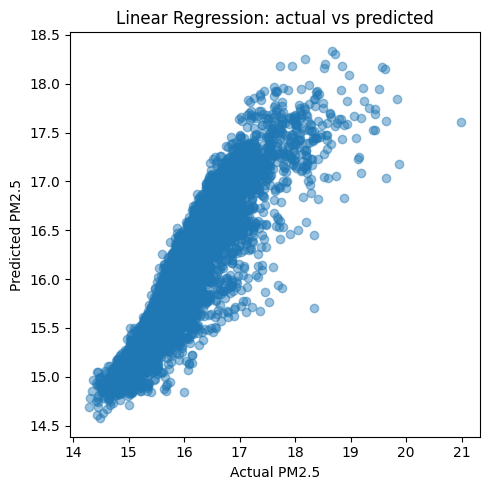

In [24]:
# Actual vs predicted plot for Linear Regression.
# Points close to a diagonal pattern mean the predictions are close to the real PM2.5 values.

plt.figure(figsize=(5,5))
plt.scatter(zte, p1, alpha=0.45)
plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("Linear Regression: actual vs predicted")
plt.tight_layout()
plt.savefig(op + "/lm_actual_pred.png", dpi=200)
plt.show()


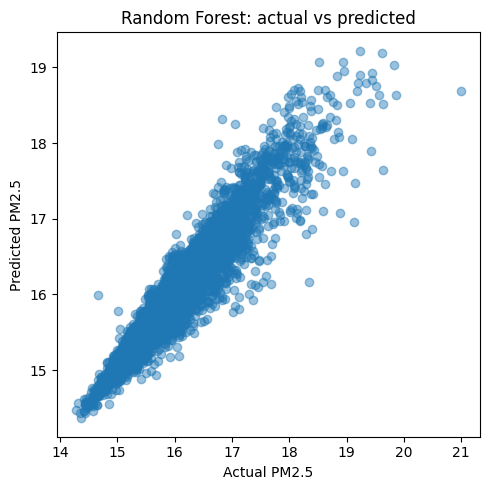

In [25]:
# Actual vs predicted plot for Random Forest.
# This plot can be compared with the Linear Regression plot above.

plt.figure(figsize=(5,5))
plt.scatter(zte, p2, alpha=0.45)
plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("Random Forest: actual vs predicted")
plt.tight_layout()
plt.savefig(op + "/rf_actual_pred.png", dpi=200)
plt.show()


In [26]:
# Random Forest feature importance.
# This is not causal interpretation.
# It only shows which variables the Random Forest used most for prediction.

im = pd.DataFrame()
im["v"] = x.columns
im["imp"] = rf.feature_importances_
im = im.sort_values("imp", ascending=False)

im.head(12).to_csv(op + "/rf_feature_importance.csv", index=False)
im.head(12)


,v,imp
4,dc2,0.449744
3,dc,0.383236
2,y,0.082480
1,x,0.042508
5,la,0.010985
0,ak,0.010948
36,b_Tower Hamlets,0.004457
26,b_Kensington and Chelsea,0.004268
19,b_Hammersmith and Fulham,0.002419
34,b_Southwark,0.001028


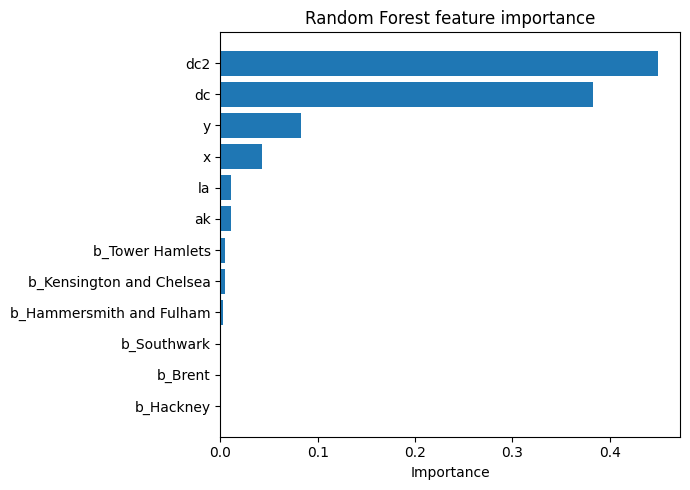

In [27]:
# Plot the top 12 important predictors.
# This gives a simple visual summary of the main variables used by the Random Forest.

im1 = im.head(12)

plt.figure(figsize=(7,5))
plt.barh(im1["v"], im1["imp"])
plt.xlabel("Importance")
plt.title("Random Forest feature importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(op + "/rf_importance.png", dpi=200)
plt.show()


In [28]:
# Make a test-set map for prediction errors.
# er = actual PM2.5 - predicted PM2.5.
# Positive residual means the model under-predicted PM2.5.
# Negative residual means the model over-predicted PM2.5.

tm = g.loc[xte.index].copy()
tm["act"] = zte
tm["prd"] = p2
tm["er"] = tm["act"] - tm["prd"]
tm["ae"] = abs(tm["er"])


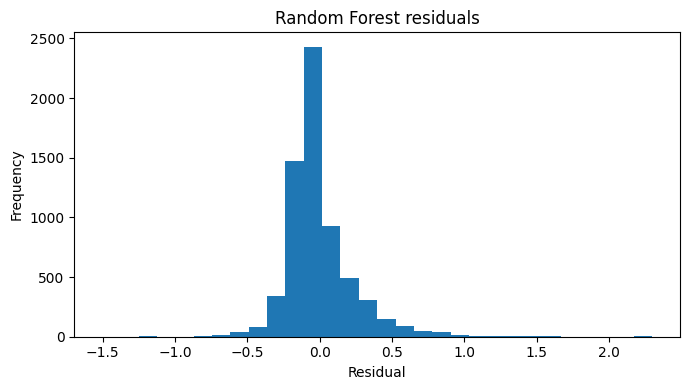

In [29]:
# Residual histogram.
# This checks whether the Random Forest errors are mostly around zero.

plt.figure(figsize=(7,4))
plt.hist(tm["er"], bins=30)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Random Forest residuals")
plt.tight_layout()
plt.savefig(op + "/rf_residual_hist.png", dpi=200)
plt.show()


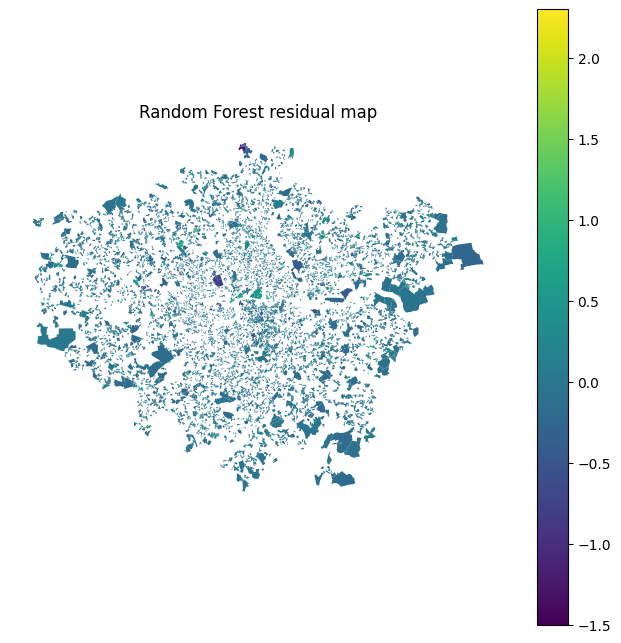

In [30]:
# Residual map.
# This shows where the Random Forest is under-predicting or over-predicting PM2.5.
# It helps connect model evaluation back to the spatial question.

tm.plot(column="er", legend=True, figsize=(8,8))
plt.title("Random Forest residual map")
plt.axis("off")
plt.savefig(op + "/rf_residual_map.png", dpi=200, bbox_inches="tight")
plt.show()


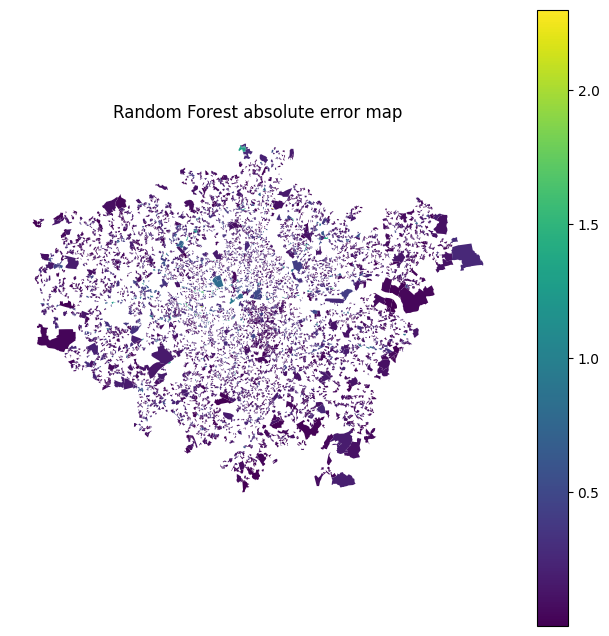

In [31]:
# Absolute error map.
# This map ignores the direction of error and only shows the size of the error.
# It is useful for identifying areas where the model is least accurate.

tm.plot(column="ae", legend=True, figsize=(8,8))
plt.title("Random Forest absolute error map")
plt.axis("off")
plt.savefig(op + "/rf_abs_error_map.png", dpi=200, bbox_inches="tight")
plt.show()


In [32]:
# Borough-level summary of prediction error.
# This is only made if the borough column exists in the shapefile.
# It gives another way to discuss where the prediction errors are larger.

if bc is not None:
    be = tm.groupby(bc)["ae"].mean().sort_values(ascending=False).head(10)
    be = be.reset_index()
    be.columns = ["borough", "mean_abs_error"]
    be["mean_abs_error"] = be["mean_abs_error"].round(4)
    be.to_csv(op + "/borough_error_top10.csv", index=False)
    be


## 8. Limitations

This study still has several limitations. The PM2.5 data come from 2013, so the results mainly reflect the spatial pattern of air pollution in London at that time and cannot directly represent the current situation. In recent years, London’s transport policies, low-emission zone development, and urban growth may have changed the spatial distribution of pollution. The explanatory variables used in this study are mainly derived from spatial boundary data, including area size, centroid coordinates, distance to the city centre, and borough categorical variables. These variables can describe spatial location, but they cannot directly represent specific pollution sources. Variables such as road density, traffic volume, land use, green space coverage, population density, and meteorological conditions are not included in the model. Although Random Forest shows strong predictive performance, it is not a causal model. Variable importance only indicates which variables the model relies on during prediction, and does not prove that these variables directly cause PM2.5 levels to increase or decrease.



## 9. Conclusion

This study examines whether basic urban spatial features can predict differences in PM2.5 exposure at the London OA level. The results show that simple GIS features already contain strong predictive information. Linear Regression clearly outperforms the Mean Baseline model, indicating that spatial features can explain a considerable proportion of PM2.5 variation. Random Forest achieves the best performance, with an R² of 0.9064, suggesting that non-linear models are more suitable for capturing spatial differences in PM2.5 within London.

Future research could incorporate variables related to road traffic, land use, green space, population, and meteorological conditions to improve the explanatory power of the model and provide a deeper understanding of the urban mechanisms behind spatial differences in PM2.5 across London.


## References

Azmi, W. N. F. W., Pillai, T. R., Latif, M. T., Koshy, S., & Shaharudin, R. (2023). Application of land use regression model to assess outdoor air pollution exposure: A review. *Environmental Advances, 11*, 100353. https://doi.org/10.1016/j.envadv.2023.100353

Breiman, L. (2001). Random forests. *Machine Learning, 45*(1), 5–32. https://doi.org/10.1023/A:1010933404324

Greater London Authority. (2016). *PM2.5 map and exposure data*. London Datastore. https://data.london.gov.uk/dataset/pm25-map-and-exposure-data-29z1y

Greater London Authority. (n.d.). *Statistical GIS boundary files for London*. London Datastore. https://data.london.gov.uk/dataset/statistical-gis-boundary-files-for-london-20od9

Hoek, G., Beelen, R., de Hoogh, K., Vienneau, D., Gulliver, J., Fischer, P., & Briggs, D. (2008). A review of land-use regression models to assess spatial variation of outdoor air pollution. *Atmospheric Environment, 42*(33), 7561–7578. https://doi.org/10.1016/j.atmosenv.2008.05.057

World Health Organization. (2021). *WHO global air quality guidelines: particulate matter (PM2.5 and PM10), ozone, nitrogen dioxide, sulfur dioxide and carbon monoxide*. World Health Organization. https://www.who.int/publications/i/item/9789240034228
